In [1]:
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime

# Read dataset:
- ds_a -- aerosol relateted dataset
- ds_c -- cloud property from mfrsrcldod1minC1
- ds_c_h -- resampled cloud height: top height bese height

In [2]:
ds_a = xr.open_mfdataset('/data/ggong/ARM_monthly/SGP/rlprof_resample_2min.nc')
ds_c = xr.open_mfdataset('/data/ggong/ARM_monthly/SGP/mfrsrcldod1minC1.c1/mfrsrcldod_*_2min_resample.nc')
ds_c_h = xr.open_mfdataset('/data/ggong/ARM_monthly/SGP/cloud_height_2min_time_spot.nc')

ds_mete = xr.open_dataset('/data/ggong/ARM_monthly/SGP/RH_T_VWS_LTS_2min_extend.nc')
ds_vv = xr.open_dataset('/data/ggong/ARM_monthly/SGP/VV_2min_750_850_extend.nc')
ds_vv600 = xr.open_dataset('/data/ggong/ARM_monthly/SGP/VV_2min_600_extend.nc')

ds_mete2 = xr.open_dataset('/data/ggong/ARM_monthly/SGP/RH34_T34_Tsurf_Windsurf_2min_extend.nc')
ds_lts2 = xr.open_dataset('/data/ggong/ARM_monthly/SGP/LTS_cloud_top_plus_2_extend.nc')

In [3]:
COD = ds_c.COD.values
Re  = ds_c.Re.values
lwp = ds_c.LWP.values*1000
CF  = ds_c.CF.values

## Dust Height / Thickness quality control

In [4]:
# 1) 取单层云的 base/top，并派生 thickness / mean height
clb_km = ds_c_h["cloud_layer_base_height"] / 1000.0
clt_km = ds_c_h["cloud_layer_top_height"]  / 1000.0

valid_layer = (np.isfinite(clb_km) & np.isfinite(clt_km) & (clb_km >= 0) & (clt_km >= 0))
n_layers = valid_layer.sum(dim="layer")                    # 每个时刻有效层数
sel_idx  = valid_layer.astype(int).argmax(dim="layer")     # 有效层的“位置”
sel_idx  = sel_idx.where(n_layers == 1)                    # 只保留单层云，其他 NaN

def take_by_idx(arr_1d, idx_scalar):
    if np.isnan(idx_scalar):
        return np.nan
    return arr_1d[int(idx_scalar)]

clb_1 = xr.apply_ufunc(
    take_by_idx, clb_km, sel_idx,
    input_core_dims=[["layer"], []],
    output_core_dims=[[]],
    vectorize=True, dask="parallelized",
    output_dtypes=[clb_km.dtype],
).rename("cloud_base_height")

clt_1 = xr.apply_ufunc(
    take_by_idx, clt_km, sel_idx,
    input_core_dims=[["layer"], []],
    output_core_dims=[[]],
    vectorize=True, dask="parallelized",
    output_dtypes=[clt_km.dtype],
).rename("cloud_top_height")

cloud_thickness = (clt_1 - clb_1).rename("cloud_geometric_thickness")
cloud_mean_h    = ((clt_1 + clb_1) * 0.5).rename("cloud_mean_height")

# 2) QC：base/top < 8 km
qc_mask = (clb_1 < 8.0) & (clt_1 < 8.0)

clb_qc = clb_1.where(qc_mask)
clt_qc = clt_1.where(qc_mask)
thk_qc = cloud_thickness.where(qc_mask)
mhn_qc = cloud_mean_h.where(qc_mask)

# 3) 计算云顶温度（按云顶高度在 ds_a 的 height_high 上做“最近邻”索引；全向量化）
heights = ds_a["height_high"].values              # (H,)
cth     = clt_qc.values                           # (T,)

T = len(cth)
idx = np.full(T, np.nan, dtype=float)

mask_cth = np.isfinite(cth)
# 对每个有效时刻，找与云顶高度最接近的垂直层索引
idx[mask_cth] = np.abs(heights[np.newaxis, :] - cth[mask_cth, np.newaxis]).argmin(axis=1).astype(float)

# 根据 idx 取出温度
temp2d   = ds_a["temperature"].values            # (T, H)
temp_cth = np.full(T, np.nan, dtype=np.float32)
valid_idx = ~np.isnan(idx)
temp_cth[valid_idx] = temp2d[np.arange(T)[valid_idx], idx[valid_idx].astype(int)]

temperature_at_cth = xr.DataArray(
    temp_cth, coords={"time": clt_qc.time}, dims="time", name="temperature_at_cth"
)

# 4) 组装数据集并进行“暖云”筛选
ds_cloud_heights = xr.Dataset(
    {
        "cloud_base_height": clb_qc,
        "cloud_top_height": clt_qc,
        "cloud_geometric_thickness": thk_qc,
        "cloud_mean_height": mhn_qc,
        "temperature_at_cth": temperature_at_cth,
    }
)

T_K_WARM = 273.15
warm_mask = ds_cloud_heights["temperature_at_cth"] > T_K_WARM
ds_cloud_heights = ds_cloud_heights.where(warm_mask)

## Dust Height / Thickness quality control

In [5]:
# ===== 参数 =====
valid_classes = [3, 9, 21, 37]
aerosol_class = 3
rain_class = 9
cloud_class = 21

dep_m  = 0.0049
dep_d  = 0.31
dep_nd = 0.15

hmin_km, hmax_km = 0.03, 8.0
ext_thresh = 1.25

# ====================== QC ======================
mask_qc = (
    (ds_a["detection_confidence_score_total"] >= 0.3)
    & (ds_a["qc_profile"] == 0)
    & ~(ds_a["feature_mask"] == 9).any(dim="height_high")
)

feature_mask = ds_a["feature_mask"].where(mask_qc)
pdr_meas     = ds_a["depolarization_ratio"].where(mask_qc)
ext          = ds_a["extinction_be"].where(mask_qc)
sca          = ds_a["scattering_ratio_e"].where(mask_qc)

# ====================== keep valid class ======================
mask_class = xr.zeros_like(feature_mask, dtype=bool)
for val in valid_classes:
    mask_class = mask_class | (feature_mask == val)

feature_mask = feature_mask.where(mask_class)
pdr_meas     = pdr_meas.where(mask_class)
ext          = ext.where(mask_class)
sca          = sca.where(mask_class)

# ====================== aerosol-only mask ======================
aerosol_mask = (feature_mask == aerosol_class)  & np.isfinite(ext) & (ext < ext_thresh)
pdr_meas_aerosol = pdr_meas.where(aerosol_mask)
sca_aerosol      = sca.where(aerosol_mask)
ext_aerosol      = ext.where(aerosol_mask)

# ====================== calculate PDR ======================
tepo = sca_aerosol + (sca_aerosol * dep_m) - dep_m
xnum = tepo * pdr_meas_aerosol - dep_m
xden = sca_aerosol - 1 + (sca_aerosol * dep_m) - pdr_meas_aerosol

eps = 1e-6
pdr = (xnum / xden).where(np.isfinite(xden) & (np.abs(xden) > eps))
pdr = pdr.where(np.isfinite(pdr) & (pdr >= 0) & (pdr <= 1.0))

# ====================== calculate dust fraction ======================
dust_frac = ((pdr - dep_nd) * (1 + dep_d)) / ((dep_d - dep_nd) * (1 + pdr))
dust_frac = dust_frac.where(pdr < dep_d, 1.0)
dust_frac = dust_frac.where(pdr > dep_nd, 0.0)
dust_frac = dust_frac.where(aerosol_mask)

# ====================== dust / non-dust extinction ======================
ext_dust    = dust_frac * ext_aerosol
ext_nondust = (1 - dust_frac) * ext_aerosol

# ====================== column AOD ======================
dz2d = xr.ones_like(ext_aerosol) * 0.03

AOD         = (ext_aerosol * dz2d).sum("height_high", min_count=1)
dust_AOD    = (ext_dust * dz2d).sum("height_high", min_count=1)
nondust_AOD = (ext_nondust * dz2d).sum("height_high", min_count=1)

In [6]:
# ===================================================================
# =============== 主尘层识别 + 高度特征计算（dust_*） ================
# ===================================================================

# 高度坐标（km）
z = ds_a["height_high"].values.astype(float)

# 相邻层厚（km），用于积分权重
dz_km = np.empty_like(z, dtype=float)
if len(z) < 2:
    raise ValueError("height_high 维度长度不足，无法计算 dz")
dz_km[0]  = (z[1] - z[0])
dz_km[1:] = np.diff(z)

# 只保留正的 dust extinction；NaN 保留为缺测
dust_ext = xr.where(ext_dust > 0, ext_dust, np.nan)
dust_mask_arr = xr.where(ext_dust > 0, True, False).fillna(False).values  # (time, height)
dust_ext_arr  = dust_ext.values                                           # (time, height)

T, H = dust_mask_arr.shape

base_km  = np.full(T, np.nan, dtype=float)  # dust_base_height
top_km   = np.full(T, np.nan, dtype=float)  # dust_top_height
mean_km  = np.full(T, np.nan, dtype=float)  # dust_mean_height = (base+top)/2
scale_km = np.full(T, np.nan, dtype=float)  # dust_scale_height (e-fold above base)
cent_km  = np.full(T, np.nan, dtype=float)  # dust_centroid_height (ext-weighted)
main_dod = np.full(T, np.nan, dtype=float)  # main dust optical depth

for t in range(T):
    m = dust_mask_arr[t]   # bool profile
    e = dust_ext_arr[t]    # dust extinction profile

    if not np.any(m):
        continue

    # ---- 找到所有连续 True 的尘层段 ----
    mm = m.astype(int)
    edges  = np.diff(np.concatenate(([0], mm, [0])))
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0] - 1  # inclusive

    if starts.size == 0:
        continue

    # ---- 选“主尘层”：层内 dust AOD（∑ ext_dust * dz_km）最大的段 ----
    best_idx = None
    best_int = -np.inf
    for s, eidx in zip(starts, ends):
        layer_ext = dust_ext_arr[t, s:eidx+1]
        layer_dz  = dz_km[s:eidx+1]
        integ = np.nansum(layer_ext * layer_dz)
        if np.isfinite(integ) and (integ > best_int):
            best_int = integ
            best_idx = (s, eidx)

    if best_idx is None:
        continue

    s, eidx = best_idx
    base_km[t] = z[s]
    top_km[t]  = z[eidx]
    mean_km[t] = 0.5 * (base_km[t] + top_km[t])

    layer_ext = dust_ext_arr[t, s:eidx+1]
    layer_z   = z[s:eidx+1]
    layer_dz  = dz_km[s:eidx+1]

    # ---- 主尘层 DOD ----
    main_dod[t] = np.nansum(layer_ext * layer_dz)

    # ---- 质心（主尘层内的 dust extinction 加权）: ∫z*ext*dz / ∫ext*dz ----
    m_valid = np.isfinite(layer_ext) & (layer_ext > 0)
    if np.count_nonzero(m_valid) > 0:
        num = np.nansum(layer_ext[m_valid] * layer_z[m_valid] * layer_dz[m_valid])
        den = np.nansum(layer_ext[m_valid] *                 layer_dz[m_valid])
        if den > 0 and np.isfinite(num):
            cent_km[t] = num / den

    # ---- 尺度高度：自层底 ext0 衰减到 ext0/e 的高度差（log 空间线性插值）----
    valid0 = np.where(np.isfinite(layer_ext) & (layer_ext > 0))[0]
    if valid0.size == 0:
        continue

    s0 = valid0[0]
    ext0 = layer_ext[s0]
    target = ext0 / np.e
    eps = 1e-12
    found = False

    for k in range(s0, len(layer_ext) - 1):
        y1, y2 = layer_ext[k], layer_ext[k+1]
        if not (np.isfinite(y1) and np.isfinite(y2) and y1 > eps and y2 > eps):
            continue
        if (y1 >= target and y2 <= target) or (y1 <= target and y2 >= target):
            z1, z2   = layer_z[k], layer_z[k+1]
            ly1, ly2 = np.log(y1), np.log(y2)
            ltar     = np.log(target)
            frac = (ltar - ly1) / (ly2 - ly1) if ly2 != ly1 else 0.0
            z_star = z1 + frac * (z2 - z1)
            scale_km[t] = z_star - layer_z[s0]
            found = True
            break

    if not found:
        y_top = layer_ext[-1]
        if np.isfinite(y_top) and y_top > eps and ext0 > eps and (ext0 / y_top) > 1.0:
            scale_km[t] = (layer_z[-1] - layer_z[s0]) / np.log(ext0 / y_top)
        else:
            scale_km[t] = np.nan

# ====================== 打包结果 ======================
time_coord = ds_a["time"]
ds_dust_heights = xr.Dataset(
    data_vars=dict(
        dust_base_height = xr.DataArray(base_km, coords={"time": time_coord}, dims="time",
            attrs={"units":"km","long_name":"Dust layer base height (main dust layer)"}),
        dust_top_height  = xr.DataArray(top_km,  coords={"time": time_coord}, dims="time",
            attrs={"units":"km","long_name":"Dust layer top height (main dust layer)"}),
        dust_mean_height = xr.DataArray(mean_km, coords={"time": time_coord}, dims="time",
            attrs={"units":"km","long_name":"Mean dust height μ=(base+top)/2 (main dust layer)"}),
        dust_scale_height= xr.DataArray(scale_km,coords={"time": time_coord}, dims="time",
            attrs={"units":"km","long_name":"Dust scale height H (e-fold above base, main dust layer)"}),
        dust_centroid_height = xr.DataArray(cent_km, coords={"time": time_coord}, dims="time",
            attrs={"units":"km","long_name":"Dust extinction-weighted centroid height (main dust layer)"}),
        main_dod = xr.DataArray(main_dod, coords={"time": time_coord}, dims="time",
            attrs={"units":"1","long_name":"Dust optical depth of main dust layer"}),
    )
)

# （可选）附加层厚 ΔZ
ds_dust_heights["dust_layer_thickness"] = (
    ds_dust_heights["dust_top_height"] - ds_dust_heights["dust_base_height"]
)
ds_dust_heights["dust_layer_thickness"].attrs.update(
    {"units":"km","long_name":"Dust layer thickness ΔZ"}
)

## Aerosol-cloud collocation

In [7]:
dust_top_height  = ds_dust_heights["dust_top_height"].values
dust_base_height  = ds_dust_heights["dust_base_height"].values
dust_thickness = ds_dust_heights["dust_layer_thickness"].values
dust_mean_height = ds_dust_heights["dust_mean_height"].values

cloud_top_height  = ds_cloud_heights["cloud_top_height"].values
cloud_base_height  = ds_cloud_heights["cloud_base_height"].values
cloud_thickness = ds_cloud_heights["cloud_geometric_thickness"].values
cloud_mean_height = ds_cloud_heights["cloud_mean_height"].values

### Count the number of times each duration occurs

In [8]:
# 建立 mask: 只在所有都非 NaN 时为 True
valid_mask = (~np.isnan(dust_top_height) & ~np.isnan(dust_base_height) & ~np.isnan(cloud_top_height) & ~np.isnan(cloud_base_height))

# 初始化输出数组（复制一份原始数组）
dust_top_height_new  = dust_top_height.copy()
dust_base_height_new = dust_base_height.copy()
dust_mean_height_new = dust_mean_height.copy()
dust_thickness_new = dust_thickness.copy()

cloud_top_height_new = cloud_top_height.copy()
cloud_base_height_new = cloud_base_height.copy()
cloud_mean_height_new = cloud_mean_height.copy()
cloud_thickness_new = cloud_thickness.copy()

# 把无效位置全部设为 NaN
dust_top_height_new[~valid_mask]  = np.nan
dust_base_height_new[~valid_mask] = np.nan
dust_mean_height_new[~valid_mask]  = np.nan
dust_thickness_new[~valid_mask] = np.nan

cloud_top_height_new[~valid_mask] = np.nan
cloud_base_height_new[~valid_mask] = np.nan
cloud_mean_height_new[~valid_mask] = np.nan
cloud_thickness_new[~valid_mask] = np.nan


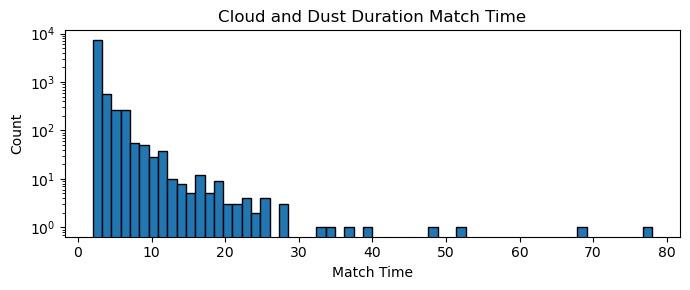

In [9]:
m = ~np.isnan(dust_top_height_new)
d = np.diff(m.astype(int))
L = np.where(d==-1)[0] - np.where(d==1)[0] + 1

plt.figure(figsize=(7,3),dpi=100)
plt.hist(L,bins=60,edgecolor="k")
plt.yscale("log")
plt.xlabel("Match Time"); plt.ylabel("Count"); plt.title("Cloud and Dust Duration Match Time")
plt.tight_layout(); plt.show()

## identify events of each cates

In [10]:
diff = np.diff(valid_mask.astype(int))
starts, ends = np.where(diff==1)[0]+1, np.where(diff==-1)[0]
if valid_mask[0]:  starts = np.r_[0, starts]
if valid_mask[-1]: ends   = np.r_[ends, len(valid_mask)-1]

class_map = {"top":0,"bottom":1,"middle":2,"decreasing":3,"increasing":4}
labels = np.full(valid_mask.shape, np.nan); categories = {k:0 for k in class_map}
cat_names = list(class_map)
for s,e in zip(starts,ends):
    sl = slice(s,e+1)
    d_top, d_base = np.nanmean(dust_top_height_new[sl]), np.nanmean(dust_base_height_new[sl])
    c_top, c_base = np.nanmean(cloud_top_height_new[sl]), np.nanmean(cloud_base_height_new[sl])
    if c_top>3.0: continue
    if   d_base-c_top>0.1: cat="top"
    elif c_base-d_top>0.1: cat="bottom"
    elif (c_base-0.1<d_base) and (c_top+0.1>d_top): cat="middle"
    elif (c_base-0.1<d_top<c_top+0.1) and (d_base<c_base-0.1): cat="decreasing"
    elif (c_base-0.1<d_base<c_top+0.1) and (d_top>c_top+0.1): cat="increasing"
    else: cat=None
    if cat: labels[s:e+1]=class_map[cat]; categories[cat]+=e-s+1

print("time sample 统计：")
print("\n".join(f"{k}: {v}" for k,v in categories.items()))

time sample 统计：
top: 1098
bottom: 6595
middle: 2762
decreasing: 240
increasing: 144


## extract the vars for further analysis, base on time sample

In [11]:
# ===================== 3. time-sample extraction for cloud/dust/microphysics =====================
cloud_mh_by_cat, dust_mh_by_cat, cloud_tn_by_cat, dust_tn_by_cat = {}, {}, {}, {}
dust_th_by_cat, dust_bh_by_cat, cloud_th_by_cat, cloud_bh_by_cat = {}, {}, {}, {}
COD_by_cat, re_by_cat, lwp_by_cat, cf_by_cat, DOD_by_cat,main_dod_by_cat = {}, {}, {}, {}, {}, {}

_pairs1 = [
    (cloud_mh_by_cat, cloud_mean_height_new),
    (dust_mh_by_cat,  dust_mean_height_new),
    (cloud_tn_by_cat, cloud_thickness_new),
    (dust_tn_by_cat,  dust_thickness_new),
    (cloud_th_by_cat, cloud_top_height_new),
    (dust_th_by_cat,  dust_top_height_new),
    (cloud_bh_by_cat, cloud_base_height_new),
    (dust_bh_by_cat,  dust_base_height_new),
    (COD_by_cat, np.asarray(ds_c.COD.values, float)),
    (re_by_cat,  np.asarray(ds_c.Re.values, float)),
    (lwp_by_cat, np.asarray(ds_c.LWP.values, float) * 1000.0),
    (cf_by_cat,  np.asarray(ds_c.CF.values, float)),
    (DOD_by_cat, np.asarray(dust_AOD.values if hasattr(dust_AOD, "values") else dust_AOD, float)),
    (main_dod_by_cat, np.asarray(ds_dust_heights.main_dod.values, float)),
]

for name in cat_names:
    m = labels == class_map[name]
    for d, arr in _pairs1:
        d[name] = np.asarray(arr, float)[m]   # 保留 NaN

# ===================== 4. time-sample extraction for meteorology =====================
RH, TEMP, VWS, LTS, VV = (
    np.asarray(ds_mete.RH_750_850.values, float),
    np.asarray(ds_mete.TEMP_750_850.values, float),
    np.asarray(ds_mete.VWS_725_925.values, float),
    np.asarray(ds_mete.LTS.values, float),
    np.asarray(ds_vv.w_750_850.values, float),
)

RH_34, TEMP_34, Wind_surf, TEMP_surf, VV_4 = (
    np.asarray(ds_mete2.RH_34.values, float),
    np.asarray(ds_mete2.T_34.values, float),
    np.asarray(ds_mete2.Wind_surf.values, float),
    np.asarray(ds_mete2.T_surf.values, float),
    np.asarray(ds_vv600.w_600.values, float),
)

lts_2 = np.asarray(ds_lts2.LTS.values, float)

RH_by_cat, TEMP_by_cat, VWS_by_cat, LTS_by_cat, VV_by_cat = {}, {}, {}, {}, {}
RH_34_by_cat, TEMP_34_by_cat, Wind_surf_by_cat, TEMP_surf_by_cat, VV_4_by_cat, lts_2_by_cat = {}, {}, {}, {}, {}, {},

_pairs2 = [
    (RH_by_cat, RH), (TEMP_by_cat, TEMP), (VWS_by_cat, VWS), (LTS_by_cat, LTS), (VV_by_cat, VV),
    (RH_34_by_cat, RH_34), (TEMP_34_by_cat, TEMP_34), (Wind_surf_by_cat, Wind_surf),
    (TEMP_surf_by_cat, TEMP_surf), (VV_4_by_cat, VV_4), (lts_2_by_cat, lts_2),
]

for name in cat_names:
    m = labels == class_map[name]
    for d, arr in _pairs2:
        d[name] = np.asarray(arr, float)[m]   # 保留 NaN

## 20 <= LWP <=300, quality contral

In [12]:
all_dicts = [
    cloud_mh_by_cat, dust_mh_by_cat,
    cloud_tn_by_cat, dust_tn_by_cat,
    cloud_th_by_cat, dust_th_by_cat,
    cloud_bh_by_cat, dust_bh_by_cat,
    COD_by_cat, DOD_by_cat,lwp_by_cat, re_by_cat, cf_by_cat,
    RH_by_cat, TEMP_by_cat, VWS_by_cat, LTS_by_cat, VV_by_cat,
    RH_34_by_cat, TEMP_34_by_cat,
    Wind_surf_by_cat, TEMP_surf_by_cat,
    VV_4_by_cat, lts_2_by_cat, main_dod_by_cat
]

def apply_mask_lwp_to_all_dicts(all_dicts, lwp_by_cat, COD_by_cat):
    categories = lwp_by_cat.keys()

    for cat in categories:
        lwp = np.asarray(lwp_by_cat[cat], float)
        cod = np.asarray(COD_by_cat[cat], float)
        keep = (20 <= lwp) & (lwp <= 300)

        for d in all_dicts:
            d[cat] = np.asarray(d[cat], float)[keep]   # 直接丢弃不符合条件的事件

    return categories


# ---- run (覆盖所有 all_dicts 中的变量) ----
categories = apply_mask_lwp_to_all_dicts(all_dicts, lwp_by_cat, COD_by_cat,)

# ---- 检查：这里统计的是“筛选后”事件数量 ----
for cat in categories:
    print(f"{cat}: {len(lwp_by_cat[cat])} valid time sample")

top: 4 valid time sample
bottom: 635 valid time sample
middle: 289 valid time sample
decreasing: 4 valid time sample
increasing: 4 valid time sample


In [13]:
import pandas as pd
import numpy as np

cats = ['top', 'middle', 'bottom']

vars_dict = {
    "cloud_mh": cloud_mh_by_cat, "dust_mh": dust_mh_by_cat,
    "cloud_tn": cloud_tn_by_cat, "dust_tn": dust_tn_by_cat,
    "cloud_th": cloud_th_by_cat, "dust_th": dust_th_by_cat,
    "cloud_bh": cloud_bh_by_cat, "dust_bh": dust_bh_by_cat,
    "COD": COD_by_cat, "lwp": lwp_by_cat, "Re": re_by_cat, "CF": cf_by_cat,
    "RH": RH_by_cat, "TEMP": TEMP_by_cat, "VWS": VWS_by_cat,
    "LTS": LTS_by_cat, "VV": VV_by_cat,
    "RH_34": RH_34_by_cat, "TEMP_34": TEMP_34_by_cat,
    "Wind_surf": Wind_surf_by_cat, "TEMP_surf": TEMP_surf_by_cat,
    "VV_4": VV_4_by_cat, "lts_2": lts_2_by_cat,
    "main_dod": main_dod_by_cat
}

dfs = []

for cat in cats:
    n = len(VV_4_by_cat[cat])
    d = {k: vars_dict[k][cat] for k in vars_dict}
    d["label"] = np.repeat(cat, n)
    dfs.append(pd.DataFrame(d))

df = pd.concat(dfs, ignore_index=True)
df = df[['label'] + [c for c in df.columns if c != 'label']]


df.to_csv("/data/ggong/ARM_monthly/SGP/csv_file/df_abs.csv", index=False)

In [14]:
labels_da = xr.DataArray(labels, dims=["time"], coords={"time": dust_AOD.time}, name="labels")
ds_aod = dust_AOD.to_dataset(name="dust_AOD") if isinstance(dust_AOD, xr.DataArray) else dust_AOD
ds_all = xr.merge([ds_aod, ds_c, ds_cloud_heights, ds_dust_heights, labels_da])

   top | Cloud median = 1.233
   top | Dust  median = 1.736
middle | Cloud median = 1.225
middle | Dust  median = 0.769
bottom | Cloud median = 1.375
bottom | Dust  median = 0.229


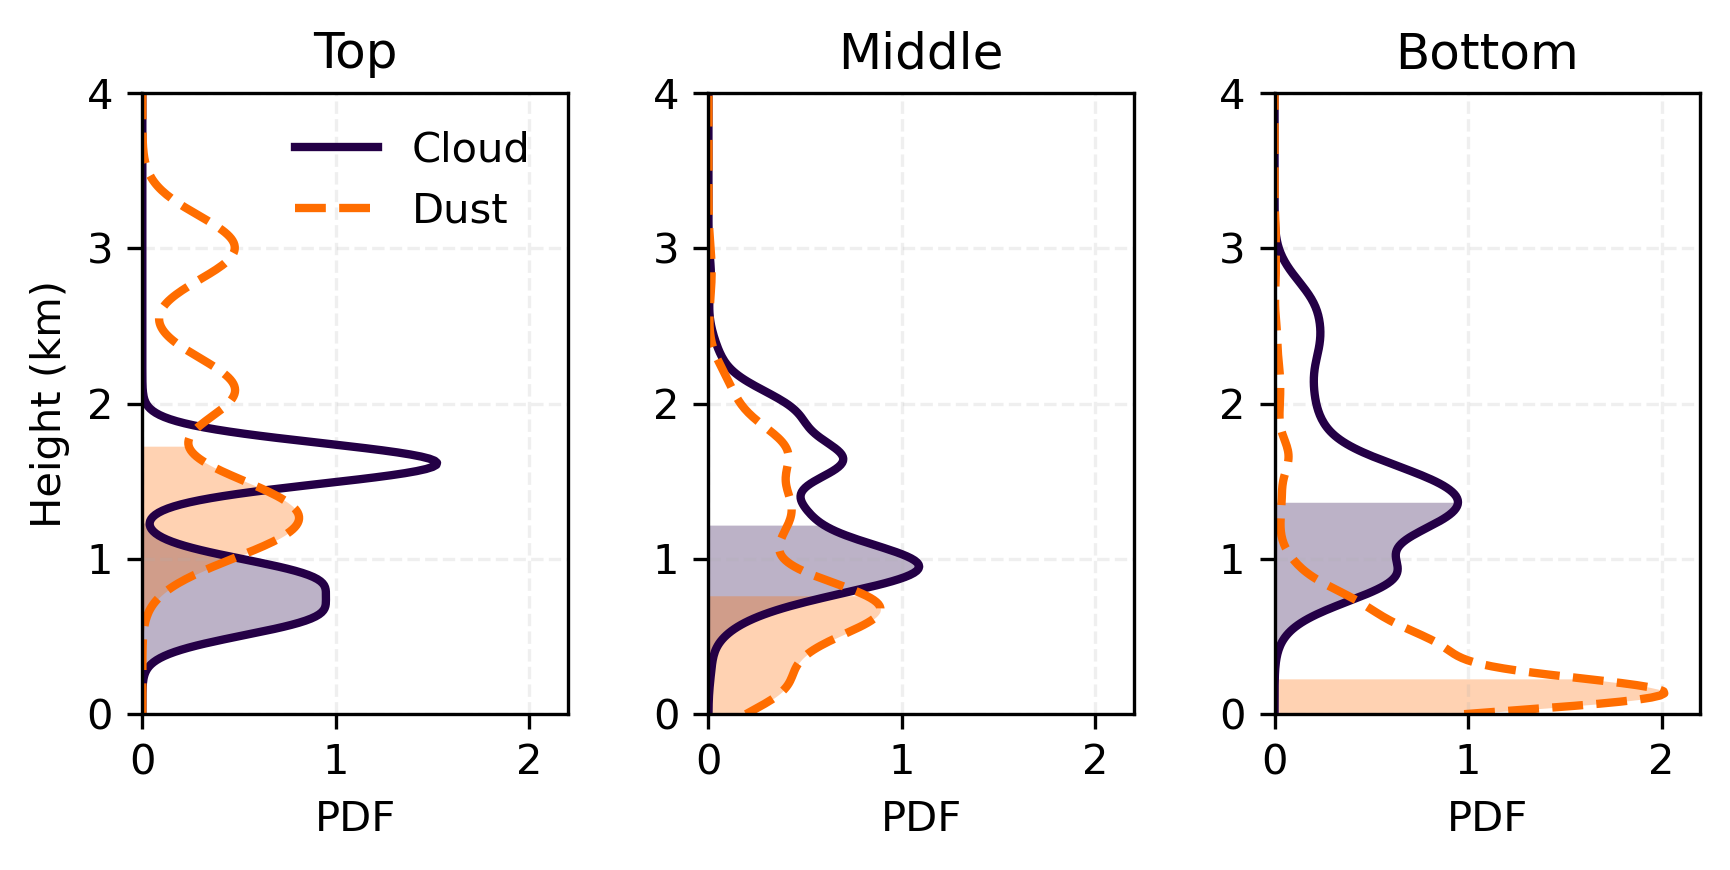

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

cats = ["top","middle","bottom"]
colors = {"Cloud":"#240046","Dust":"#ff6d00"}
styles = {"Cloud":"-","Dust":"--"}
data = {"Cloud":cloud_mh_by_cat,"Dust":dust_mh_by_cat}

xmin,xmax = 0,4; ymin,ymax = 0,2.2
x = np.linspace(xmin,xmax,300)

fig,axes = plt.subplots(1,3,figsize=(6,3),dpi=300)

for ax,c in zip(axes,cats):
    for k in ["Cloud","Dust"]:
        y = np.asarray(data[k][c],float)
        y = y[np.isfinite(y)&(y>=0)&(y<=xmax)]
        if y.size<3: continue

        kde = gaussian_kde(y,0.25)(x)
        med = np.median(y); m = x<=med

        ax.plot(kde,x,color=colors[k],lw=2,ls=styles[k],label=k)
        ax.fill_betweenx(x[m],kde[m],0,color=colors[k],alpha=0.3,lw=0)

        print(f"{c:>6s} | {k:<5s} median = {med:.3f}")

    ax.set(title=c.capitalize(),xlim=(ymin,ymax),ylim=(xmin,xmax))
    ax.grid(alpha=0.2,ls="--")

axes[0].set_ylabel("Height (km)")
for ax in axes: ax.set_xlabel("PDF")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.savefig("figsave/SGP_height.pdf", dpi=300, bbox_inches='tight')
plt.show()

DOD | top    median = 0.007
DOD | middle median = 0.005
DOD | bottom median = 0.003
COD | top    median = 15.906
COD | middle median = 18.052
COD | bottom median = 18.211
LWP | top    median = 81.784
LWP | middle median = 110.605
LWP | bottom median = 89.289
 Re | top    median = 8.379
 Re | middle median = 10.109
 Re | bottom median = 8.270


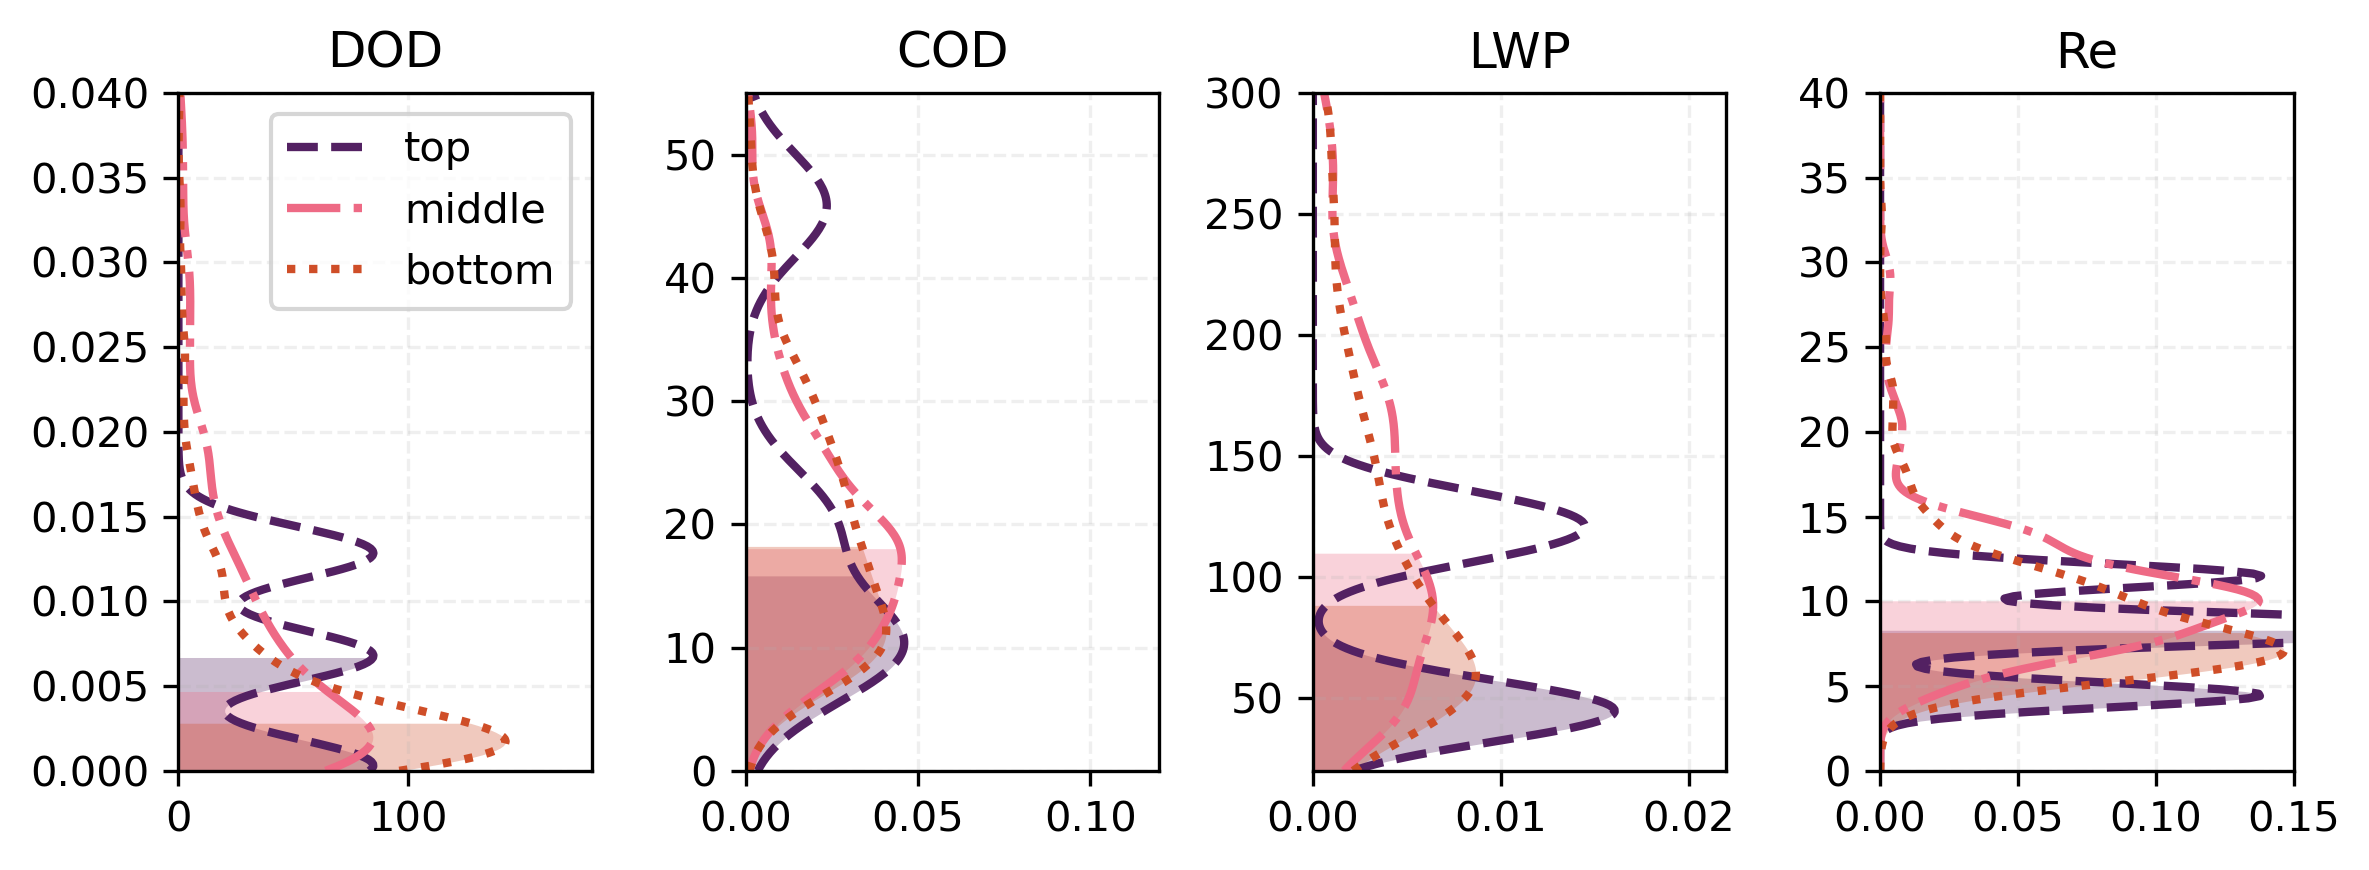

In [16]:
styles = {"top":"--","middle":"dashdot","bottom":":"}
cats = ["top","middle","bottom"]
vars4 = ["DOD","COD","LWP","Re"]
colors =  {"top":"#532162", "middle":"#ee6a85", "bottom":"#cf4e28"}
data_by_var = {"DOD":main_dod_by_cat,"COD":COD_by_cat,"LWP":lwp_by_cat,"Re":re_by_cat}

xlims = {"DOD":(0,0.04),"COD":(0,55),"LWP":(20,300),"Re":(0,40)}
ylims = {"DOD":(0,180),"COD":(0,0.12),"LWP":(0,0.022),"Re":(0,0.15)}

fig, axes = plt.subplots(1, 4, figsize=(8,3), dpi=300)

for ax, var in zip(axes, vars4):
    xmin, xmax = xlims[var]
    ymin, ymax = ylims[var]
    x = np.linspace(xmin, xmax, 300)

    for c in cats:
        y = np.asarray(data_by_var[var][c], float)
        y = y[np.isfinite(y) & (y > 0) & (xmin <= y) & (y <= xmax)]
        if y.size < 2: 
            continue

        kde = gaussian_kde(y, bw_method=0.25)(x)
        med = np.median(y)
        m = x <= med

        ax.plot(kde, x, color=colors[c], lw=2, ls=styles[c], label=c)
        ax.fill_betweenx(x[m], kde[m], 0, color=colors[c], alpha=0.3, linewidth=0)

        print(f"{var:>3s} | {c:<6s} median = {med:.3f}")

    ax.set(title=var, xlim=(ymin, ymax), ylim=(xmin, xmax))
    ax.grid(alpha=0.2, ls="--")

axes[0].legend()
plt.tight_layout()
plt.savefig("figsave/ENAPDF_v2.pdf", dpi=300, bbox_inches="tight")
plt.show()

## COD, LWP, Re as a function of DOD


LWP-stratified Re sensitivity:

LWP 20–60
  top   : sensitivity = nan, SE = nan
  middle: sensitivity = 0.044572, SE = 0.030389
  bottom: sensitivity = 0.050714, SE = 0.019511

LWP 60–100
  top   : sensitivity = nan, SE = nan
  middle: sensitivity = -0.063537, SE = 0.029895
  bottom: sensitivity = 0.011412, SE = 0.018713

LWP >100
  top   : sensitivity = nan, SE = nan
  middle: sensitivity = -0.006100, SE = 0.014509
  bottom: sensitivity = -0.002904, SE = 0.013736


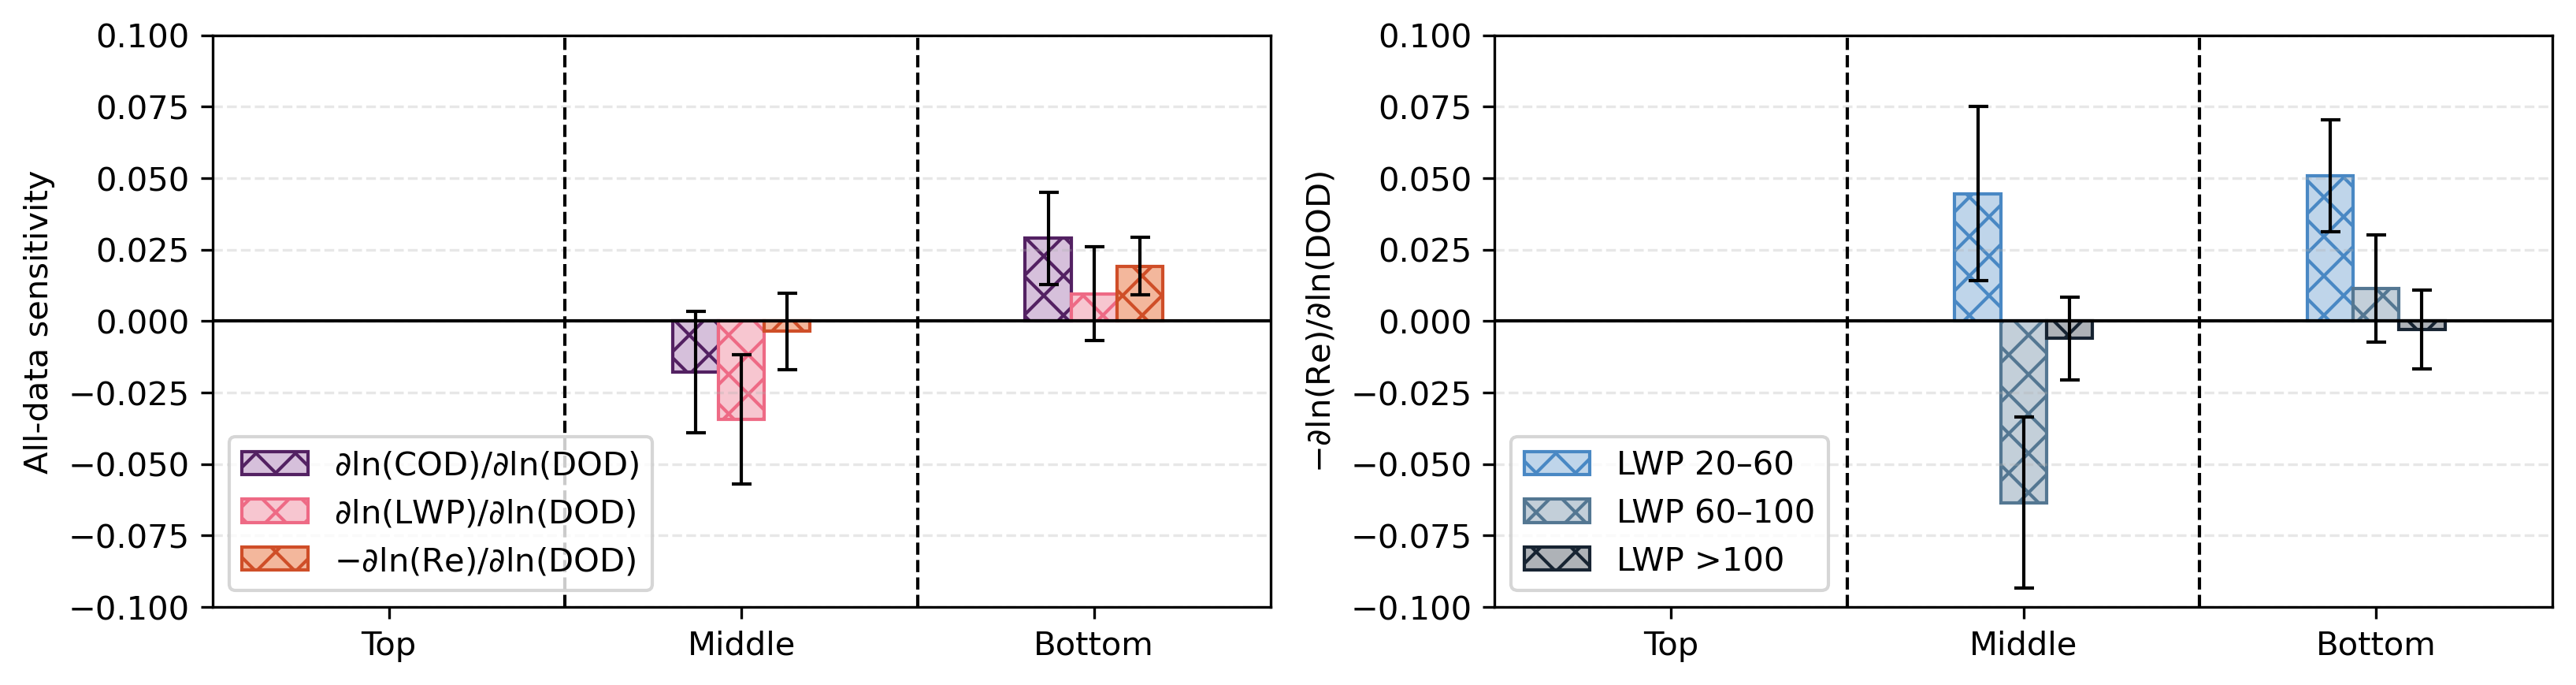

In [17]:
# settings
# =========================
cats, cat_labels = ["top", "middle", "bottom"], ["Top", "Middle", "Bottom"]
dod_min, dod_max, min_count = 1e-6, 5e-1, 20

data_by_var = {
    "DOD": {c: np.asarray(main_dod_by_cat[c], float) for c in cats},
    "COD": {c: np.asarray(COD_by_cat[c], float) for c in cats},
    "LWP": {c: np.asarray(lwp_by_cat[c], float) for c in cats},
    "Re":  {c: np.asarray(re_by_cat[c],  float) for c in cats},
}

groups = [
    ("20–60",  lambda lwp: (lwp >= 20)  & (lwp < 60)),
    ("60–100", lambda lwp: (lwp >= 60)  & (lwp < 100)),
    (">100",   lambda lwp: (lwp >= 100)),
]

cols = ["#4988C4", "#547792", "#172432"]

def _lighten(c, a=0.5):
    rgb = np.array(mcolors.to_rgb(c))
    return tuple(rgb + (1 - rgb) * a)

def calc_slope_se(x, y, xmin=dod_min, xmax=dod_max, min_count=min_count):
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) & (x >= xmin) & (x <= xmax)
    x, y = np.asarray(x[m], float), np.asarray(y[m], float)
    if x.size < min_count: return np.nan, np.nan, x.size
    r = linregress(np.log(x), np.log(y))
    return r.slope, r.stderr, x.size

# =========================
# (1) all-data sensitivity
# =========================
all_sens = {k: [] for k in ["COD", "LWP", "Re"]}
all_se   = {k: [] for k in ["COD", "LWP", "Re"]}

for c in cats:
    dod = data_by_var["DOD"][c]
    for v in ["COD", "LWP", "Re"]:
        s, se, _ = calc_slope_se(dod, data_by_var[v][c])
        if v == "Re" and np.isfinite(s): s = -s
        all_sens[v].append(s)
        all_se[v].append(se)

cod_slope, cod_se = np.asarray(all_sens["COD"]), np.asarray(all_se["COD"])
lwp_slope, lwp_se = np.asarray(all_sens["LWP"]), np.asarray(all_se["LWP"])
re_slope,  re_se  = np.asarray(all_sens["Re"]),  np.asarray(all_se["Re"])

# =========================
# (2) LWP-stratified Re sensitivity
# =========================
sens = np.full((len(groups), len(cats)), np.nan)
se   = np.full((len(groups), len(cats)), np.nan)

for j, c in enumerate(cats):
    dod, re, lwp = map(lambda v: np.asarray(v[c], float), [DOD_by_cat, re_by_cat, lwp_by_cat])
    m = np.isfinite(dod) & np.isfinite(re) & np.isfinite(lwp) & (dod > 0) & (re > 0)
    dod, re, lwp = dod[m], re[m], lwp[m]

    for i, (_, cond) in enumerate(groups):
        mm = cond(lwp)
        s, sse, _ = calc_slope_se(dod[mm], re[mm])
        if np.isfinite(s):
            sens[i, j], se[i, j] = -s, sse

# =========================
# plot
# =========================
fig, ax = plt.subplots(1, 2, figsize=(11, 3), dpi=300)
x, w = np.arange(len(cats)), 0.13
errkw = dict(ecolor="k", elinewidth=1, capsize=3, capthick=1)

# ---- (a) all data ----
ax0 = ax[0]
ax0.bar(x - w, cod_slope, w, yerr=cod_se, color="#d6c0db", edgecolor="#532162", lw=1, hatch="xx",
        error_kw=errkw, label=r"$\partial \ln(\mathrm{COD})/\partial \ln(\mathrm{DOD})$")
ax0.bar(x, lwp_slope, w, yerr=lwp_se, color="#f7c6d0", edgecolor="#ee6a85", lw=1, hatch="xx",
        error_kw=errkw, label=r"$\partial \ln(\mathrm{LWP})/\partial \ln(\mathrm{DOD})$")
ax0.bar(x + w, re_slope, w, yerr=re_se, color="#f3b79c", edgecolor="#cf4e28", lw=1, hatch="xx",
        error_kw=errkw, label=r"$-\partial \ln(\mathrm{Re})/\partial \ln(\mathrm{DOD})$")

# ---- (b) LWP stratified ----
ax1 = ax[1]
for i, (glabel, _) in enumerate(groups):
    ec, fc = cols[i], _lighten(cols[i], 0.65)
    ax1.bar(x + (i - 1) * w, sens[i], w, yerr=se[i], color=fc, edgecolor=ec, lw=1, hatch="xx",
            error_kw=errkw, label=f"LWP {glabel}")

# ---- shared formatting ----
for a, ylabel in zip(ax, ["All-data sensitivity", r"$-\partial \ln(\mathrm{Re})/\partial \ln(\mathrm{DOD})$"]):
    a.axhline(0, color="k", lw=1)
    for xpos in [0.5, 1.5]:
        a.axvline(xpos, color="k", lw=1, ls="--")
    a.set(xlim=(-0.5, 2.5), xticks=x, xticklabels=cat_labels, ylim=(-0.1, 0.1), ylabel=ylabel, )
    a.grid(axis="y", alpha=0.3, ls="--")
    a.legend()
print("\nLWP-stratified Re sensitivity:")
for i, (glabel, _) in enumerate(groups):
    print(f"\nLWP {glabel}")
    for j, c in enumerate(cats):
        print(f"  {c:<6s}: sensitivity = {sens[i, j]:.6f}, SE = {se[i, j]:.6f}")
plt.tight_layout()
plt.savefig("figsave/ENAACILWP.pdf", dpi=300, bbox_inches='tight')
plt.show()

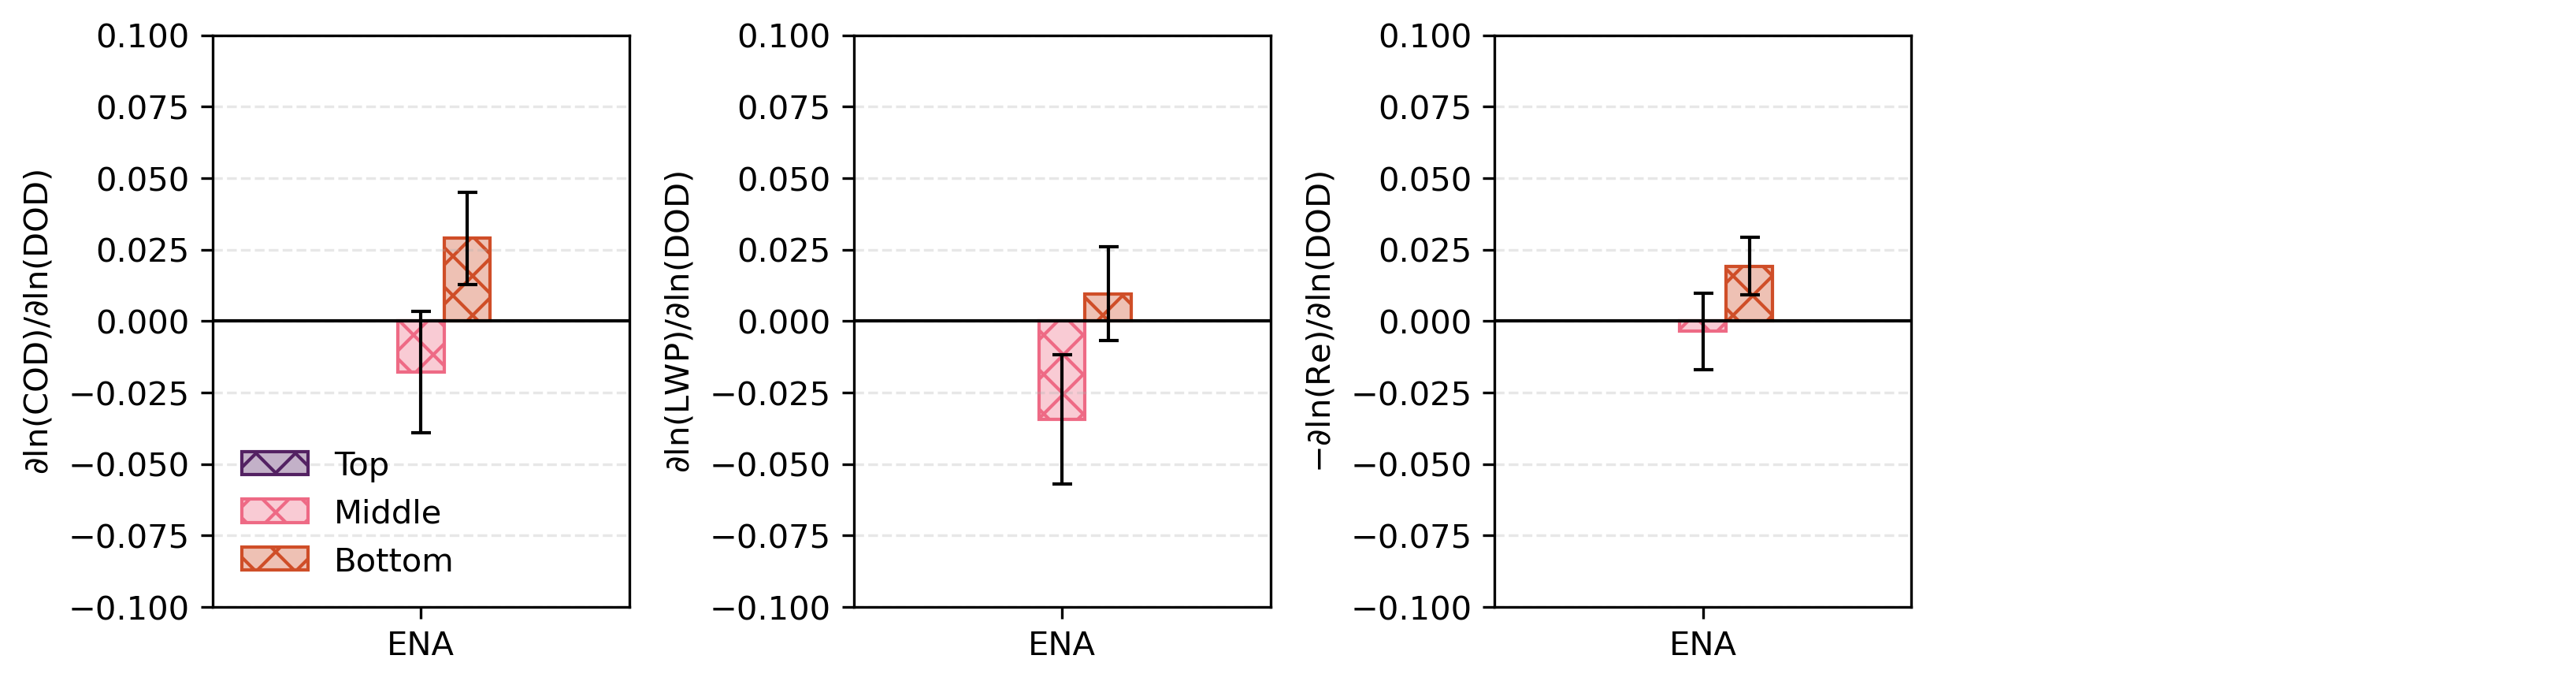


===== ACI Sensitivity Results (ENA) =====

--- COD ---
   Top : slope =  nan, SE =  nan
Middle : slope = -0.0179, SE =  0.0212
Bottom : slope =  0.0289, SE =  0.0162

--- LWP ---
   Top : slope =  nan, SE =  nan
Middle : slope = -0.0344, SE =  0.0226
Bottom : slope =  0.0095, SE =  0.0164

--- Re ---
   Top : slope =  nan, SE =  nan
Middle : slope = -0.0036, SE =  0.0133
Bottom : slope =  0.0192, SE =  0.0101


In [18]:
fig, ax = plt.subplots(1, 4, figsize=(11, 3), dpi=300)

x0, w = 0, 0.1
pos = [x0 - w, x0, x0 + w]
errkw = dict(ecolor="k", elinewidth=1, capsize=3, capthick=1)
cat_colors = {"top":"#532162", "middle":"#ee6a85", "bottom":"#cf4e28"}

vals = [
    (cod_slope, cod_se, "COD", r"$\partial \ln(\mathrm{COD})/\partial \ln(\mathrm{DOD})$"),
    (lwp_slope, lwp_se, "LWP", r"$\partial \ln(\mathrm{LWP})/\partial \ln(\mathrm{DOD})$"),
    (re_slope,  re_se,  "Re",  r"$-\partial \ln(\mathrm{Re})/\partial \ln(\mathrm{DOD})$")
]

for k, (y, yerr, title, ylabel) in enumerate(vals):
    for i, c in enumerate(cats):
        ax[k].bar(pos[i], y[i], w, yerr=yerr[i],
                  color=_lighten(cat_colors[c], 0.65),
                  edgecolor=cat_colors[c], lw=1, hatch="xx", error_kw=errkw)
    ax[k].set_ylabel(ylabel)
    ax[k].axhline(0, color="k", lw=1)
    ax[k].set(xlim=(-0.45, 0.45), ylim=(-0.1, 0.1), xticks=[0], xticklabels=[""])
    ax[k].grid(axis="y", alpha=0.3, ls="--")
    ax[k].set_xticks([0])
    ax[k].set_xticklabels(['ENA'])
ax[3].axis("off")

handles = [plt.Rectangle((0,0), 1, 1,
                         facecolor=_lighten(cat_colors[c], 0.65),
                         edgecolor=cat_colors[c], hatch="xx") for c in cats]
ax[0].legend(handles, cat_labels, frameon=False)

plt.tight_layout()
plt.savefig("figsave/ENAACI.pdf", dpi=300, bbox_inches='tight')
plt.show()
print("\n===== ACI Sensitivity Results (ENA) =====")

for (y, yerr, title, ylabel) in vals:
    print(f"\n--- {title} ---")
    for i, c in enumerate(cats):
        print(f"{c.capitalize():>6s} : slope = {y[i]: .4f}, SE = {yerr[i]: .4f}")

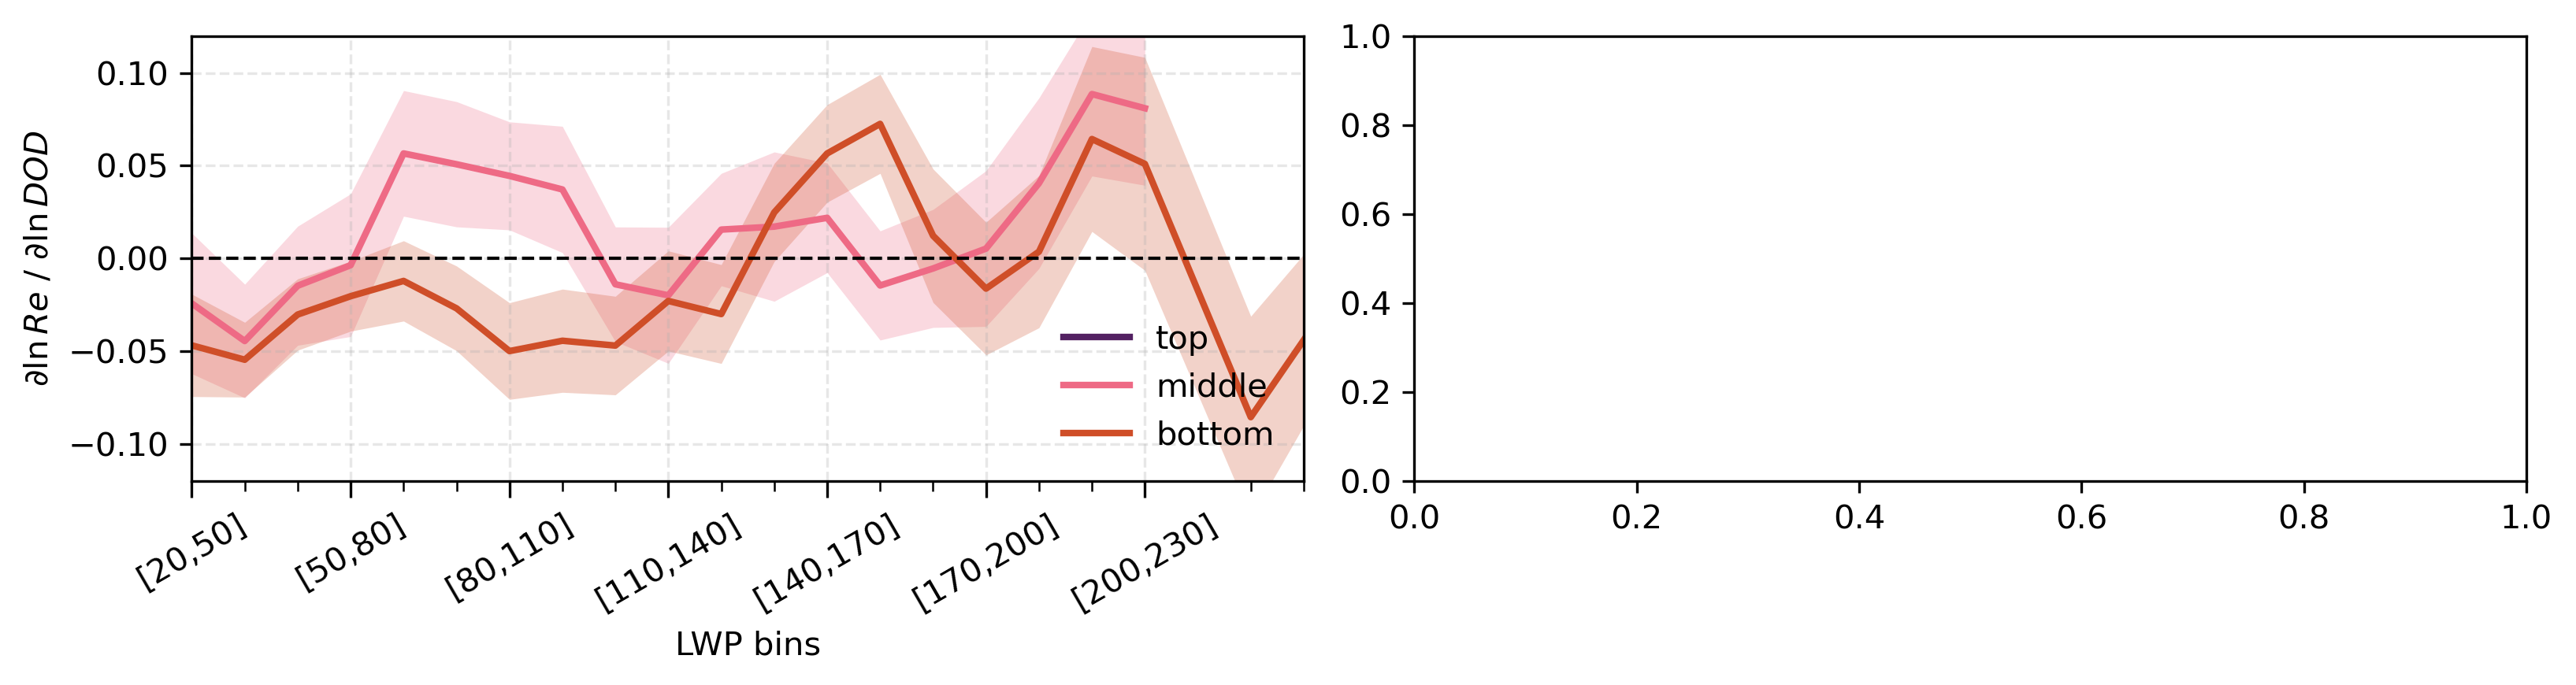

In [19]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import linregress

cats=["top","middle","bottom"]; colors={"top":"#532162","middle":"#ee6a85","bottom":"#cf4e28"}
lwp_edges=np.arange(20,231,10); window=30; dod_min,dod_max=1e-6,5e-1

def calc_slope_se(x,y):
    m=(x>0)&(y>0)&np.isfinite(x)&np.isfinite(y)
    if m.sum()<20: return np.nan,np.nan
    s,_,_,_,se=linregress(np.log(x[m]),np.log(y[m])); return s,se

fig,ax=plt.subplots(1,2,figsize=(11,3),dpi=300)

for cat in cats:
    dod,re,lwp=map(lambda v:np.asarray(v,float),(main_dod_by_cat[cat],re_by_cat[cat],lwp_by_cat[cat]))
    m=np.isfinite(dod)&np.isfinite(re)&np.isfinite(lwp)&(dod>0)&(re>0)&(dod>=dod_min)&(dod<=dod_max)
    dod,re,lwp=dod[m],re[m],lwp[m]

    centers,slopes,errors,labels=[],[],[],[]
    for s in lwp_edges:
        e=s+window; mask=(lwp>=s)&(lwp<e)
        slope,se=calc_slope_se(dod[mask],re[mask])
        if np.isfinite(slope): centers.append(s+window/2); slopes.append(slope); errors.append(se); labels.append(f"[{int(s)},{int(e)}]")

    centers,slopes,errors=map(np.array,[centers,slopes,errors])
    ax[0].plot(centers,slopes,"-",lw=2,color=colors[cat],label=cat)
    ax[0].fill_between(centers,slopes-errors,slopes+errors,color=colors[cat],alpha=0.25,linewidth=0)

# ===== ticks: 全部tick + 每3个label =====
major_idx=np.arange(0,len(centers),3)
ax[0].set_xticks(centers,minor=True)
ax[0].set_xticks(centers[major_idx])
ax[0].set_xticklabels(np.array(labels)[major_idx],rotation=30,)

ax[0].tick_params(axis='x',which='minor',length=3)
ax[0].tick_params(axis='x',which='major',length=5)

# ===== cosmetics =====
ax[0].axhline(0,color="k",ls="--",lw=1)
ax[0].set(xlabel="LWP bins",ylabel=r"$\partial \ln Re \ / \ \partial \ln DOD$",xlim=(35,245),ylim=(-0.12,0.12))
ax[0].grid(ls="--",alpha=0.3,which="major")
ax[0].legend(frameon=False)

plt.tight_layout(); plt.show()

## Influence of Meteorology Covariation


===== RH =====
   top | insufficient total samples
middle |  low | thr=72.308 | slope=-0.0011 | se=0.0213 | n=124
middle | high | thr=72.308 | slope=-0.0075 | se=0.0171 | n=165
bottom |  low | thr=72.308 | slope=-0.0327 | se=0.0142 | n=337
bottom | high | thr=72.308 | slope=0.0593 | se=0.0144 | n=298

===== T =====
   top | insufficient total samples
middle |  low | thr=11.949 | slope=0.0054 | se=0.0142 | n=213
middle | high | thr=11.949 | slope=-0.0344 | se=0.0322 | n=76
bottom |  low | thr=11.949 | slope=-0.0262 | se=0.0169 | n=249
bottom | high | thr=11.949 | slope=0.0487 | se=0.0124 | n=386

===== LTS =====
   top | insufficient total samples
middle |  low | thr=13.987 | slope=-0.0001 | se=0.0417 | n=64
middle | high | thr=13.987 | slope=-0.0005 | se=0.0142 | n=200
bottom |  low | thr=13.987 | slope=0.0486 | se=0.0165 | n=366
bottom | high | thr=13.987 | slope=-0.0068 | se=0.0135 | n=230

===== VWS =====
   top | insufficient total samples
middle |  low | thr=8.418 | slope=0.0204 

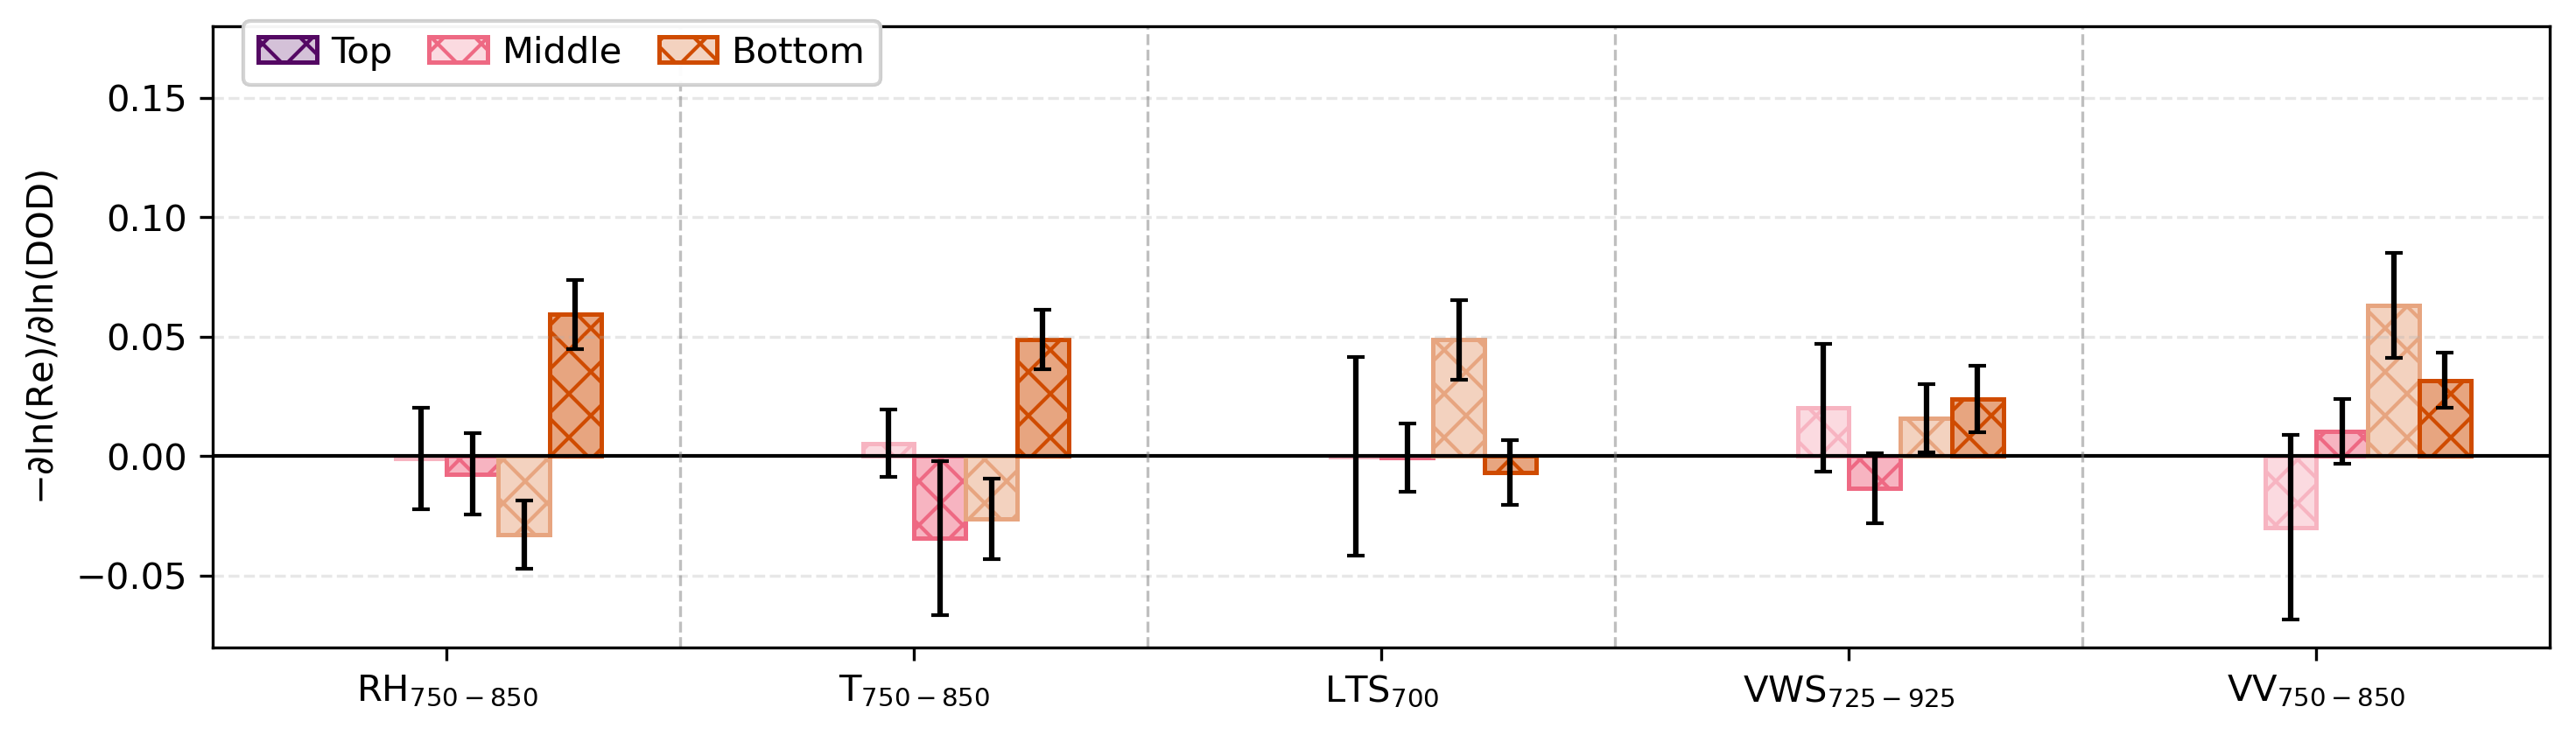


Full results:

variable category group  threshold   slope  stderr   n
      RH   middle   low    72.3076 -0.0011  0.0213 124
      RH   middle  high    72.3076 -0.0075  0.0171 165
      RH   bottom   low    72.3076 -0.0327  0.0142 337
      RH   bottom  high    72.3076  0.0593  0.0144 298
       T   middle   low    11.9494  0.0054  0.0142 213
       T   middle  high    11.9494 -0.0344  0.0322  76
       T   bottom   low    11.9494 -0.0262  0.0169 249
       T   bottom  high    11.9494  0.0487  0.0124 386
     LTS   middle   low    13.9867 -0.0001  0.0417  64
     LTS   middle  high    13.9867 -0.0005  0.0142 200
     LTS   bottom   low    13.9867  0.0486  0.0165 366
     LTS   bottom  high    13.9867 -0.0068  0.0135 230
     VWS   middle   low     8.4178  0.0204  0.0268  98
     VWS   middle  high     8.4178 -0.0134  0.0147 191
     VWS   bottom   low     8.4178  0.0159  0.0144 364
     VWS   bottom  high     8.4178  0.0240  0.0138 271
      VV   middle    <0     0.0000 -0.0297  0.038

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import linregress
from matplotlib.patches import Patch

cats = ["top", "middle", "bottom"]
cat_labels = ["Top", "Middle", "Bottom"]
base_cols = ["#540863", "#EE6983", "#CF4B00"]
dod_min, dod_max, min_count = 1e-6, 5e-1, 20

met_by_var = {
    "RH": RH_by_cat,
    "T": TEMP_by_cat,
    "LTS": LTS_by_cat,
    "VWS": VWS_by_cat,
    "VV": VV_by_cat
}
xlabels = {
    "RH": "RH$_{750-850}$",
    "T": "T$_{750-850}$",
    "LTS": "LTS$_{700}$",
    "VWS": "VWS$_{725-925}$",
    "VV": "VV$_{750-850}$"
}

def _lighten(c, a=0.5):
    rgb = np.array(mcolors.to_rgb(c))
    return tuple(rgb + (1 - rgb) * a)

def calc_slope_se(x, y):
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) & (x >= dod_min) & (x <= dod_max)
    x, y = np.asarray(x[m], float), np.asarray(y[m], float)
    if x.size < min_count:
        return np.nan, np.nan, x.size
    r = linregress(np.log(x), np.log(y))
    return -r.slope, r.stderr, x.size

vars_plot = list(met_by_var)

# 共同阈值：每个变量把 top/middle/bottom 合并后取一个中位数
thresholds = {
    v: 0.0 if v == "VV" else np.nanmedian(np.concatenate([np.asarray(met_by_var[v][c], float) for c in cats]))
    for v in vars_plot
}

results = []
fig, ax = plt.subplots(figsize=(10, 3.2), dpi=300)
group_gap, bar_w = 1.0, 0.11
centers = np.arange(len(vars_plot)) * group_gap
offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * bar_w

for k, vname in enumerate(vars_plot):
    print(f"\n===== {vname} =====")
    thr = thresholds[vname]
    for j, c in enumerate(cats):
        dod = np.asarray(main_dod_by_cat[c], float)
        re  = np.asarray(re_by_cat[c], float)
        met = np.asarray(met_by_var[vname][c], float)

        m = np.isfinite(dod) & np.isfinite(re) & np.isfinite(met) & (dod > 0) & (re > 0)
        dod, re, met = dod[m], re[m], met[m]
        if dod.size < min_count:
            print(f"{c:>6} | insufficient total samples")
            continue

        groups = [met < 0, met >= 0] if vname == "VV" else [met < thr, met >= thr]
        gnames = ["<0", "≥0"] if vname == "VV" else ["low", "high"]

        base = base_cols[j]
        ecs = [_lighten(base, 0.5), base]
        fcs = [_lighten(ecs[0], 0.5), _lighten(ecs[1], 0.5)]

        for i, (gname, mm) in enumerate(zip(gnames, groups)):
            slope, se, n = calc_slope_se(dod[mm], re[mm])
            results.append([vname, c, gname, thr, slope, se, n])
            print(f"{c:>6} | {gname:>4} | thr={thr:.3f} | slope={slope:.4f} | se={se:.4f} | n={n}")
            ax.bar(
                centers[k] + offsets[j*2+i], slope, bar_w, yerr=se, capsize=2.5,
                facecolor=fcs[i], edgecolor=ecs[i], linewidth=1.2, hatch="xx"
            )

ax.axhline(0, color="k", lw=1)
bounds = np.r_[centers[0]-group_gap/2, (centers[:-1]+centers[1:])/2, centers[-1]+group_gap/2]
for xc in bounds[1:-1]:
    ax.axvline(xc, color="gray", lw=0.8, ls="--", alpha=0.5)

ax.set_xlim(bounds[0], bounds[-1])
ax.set_ylim(-0.08, 0.18)
ax.set_xticks(centers)
ax.set_xticklabels([xlabels[v] for v in vars_plot])
ax.set_ylabel(r"$-\partial \ln(\mathrm{Re}) / \partial \ln(\mathrm{DOD})$")
ax.grid(axis="y", ls="--", alpha=0.3)

leg1 = ax.legend(
    handles=[Patch(facecolor=_lighten(_lighten(c, 0.5), 0.5), edgecolor=c, hatch="xx", label=l, linewidth=1.2)
             for c, l in zip(base_cols, cat_labels)],
    loc="upper left", ncol=3, frameon=True, bbox_to_anchor=(0.01, 1.02),
    borderaxespad=0.2, handlelength=1.6, handletextpad=0.4, columnspacing=1.0
)
ax.add_artist(leg1)

plt.subplots_adjust(left=0.09, right=0.98, bottom=0.16, top=0.90)
fig.savefig("figsave/mete_SGP_new1_common_threshold.pdf", dpi=300, bbox_inches="tight")
plt.show()

df_res = pd.DataFrame(results, columns=["variable", "category", "group", "threshold", "slope", "stderr", "n"])
pd.set_option("display.precision", 4)
print("\nFull results:\n")
print(df_res.to_string(index=False))
# df_res.to_csv("figsave/mete_ENA_new1_common_threshold_results.csv", index=False)

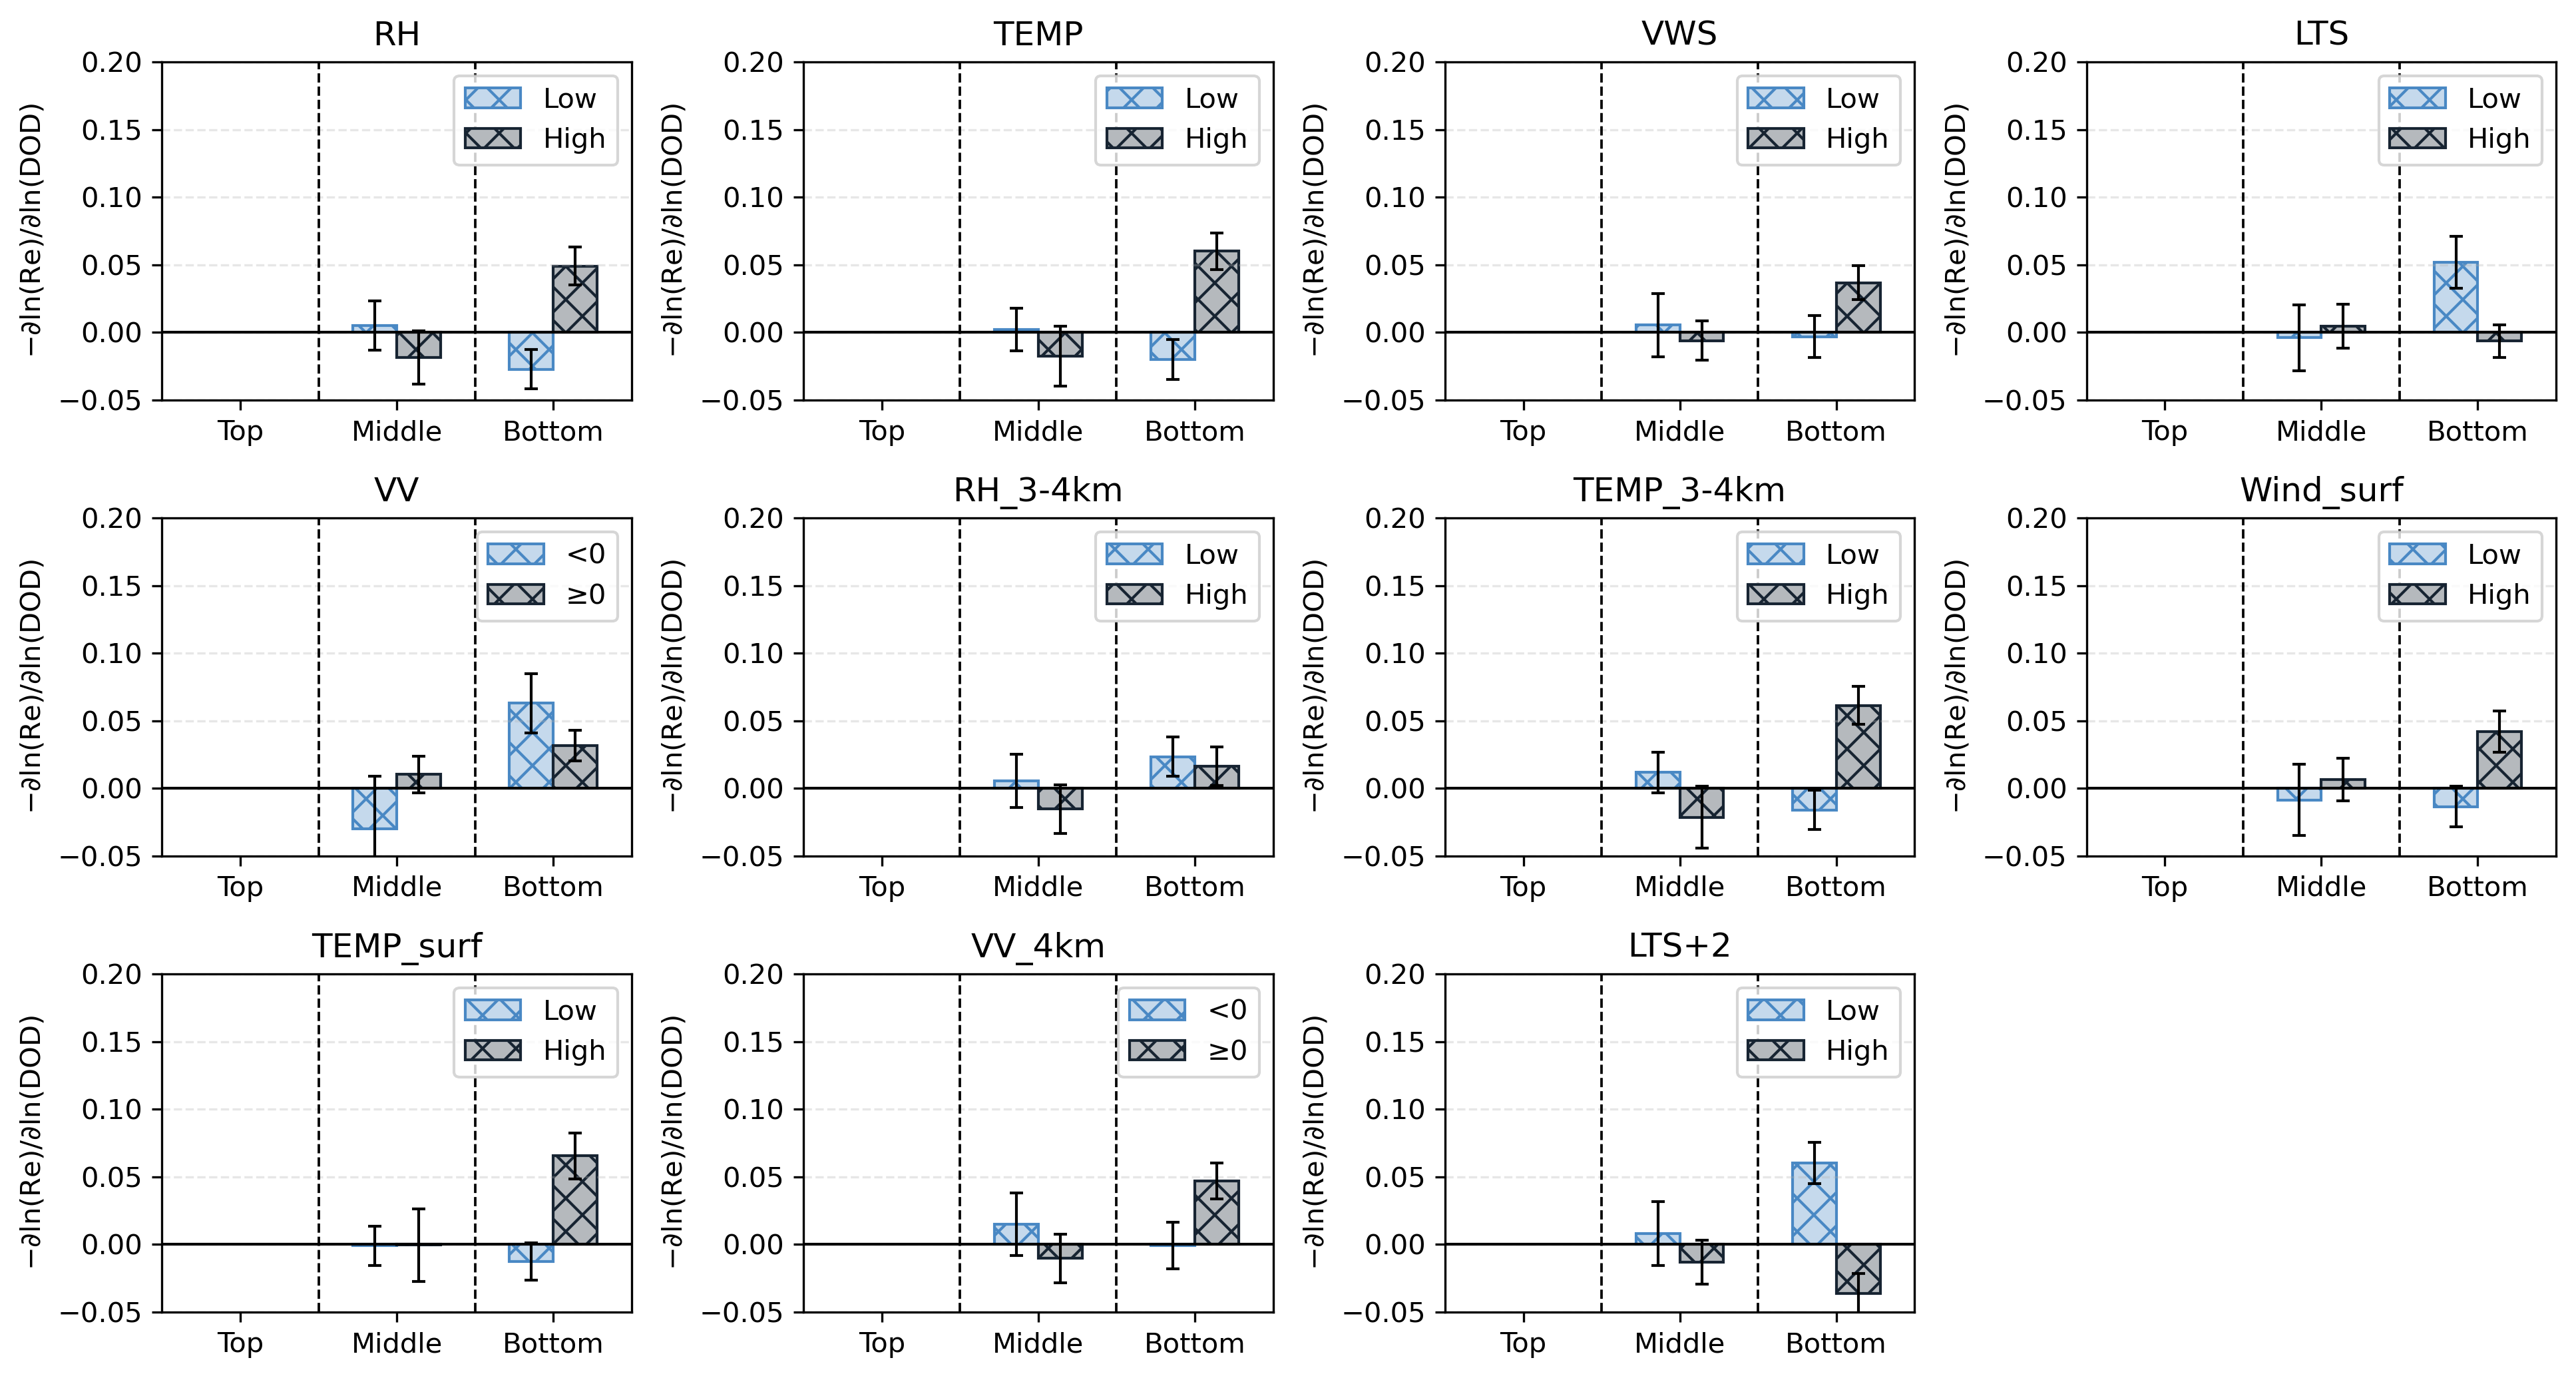

In [21]:
# =========================
# settings
# =========================
cats = ["top", "middle", "bottom"]
cat_labels = ["Top", "Middle", "Bottom"]
dod_min, dod_max, min_count = 1e-6, 5e-1, 20

met_by_var = {
    "RH": RH_by_cat, "TEMP": TEMP_by_cat, "VWS": VWS_by_cat, "LTS": LTS_by_cat,
    "VV": VV_by_cat, "RH_3-4km": RH_34_by_cat, "TEMP_3-4km": TEMP_34_by_cat,
    "Wind_surf": Wind_surf_by_cat, "TEMP_surf": TEMP_surf_by_cat,
    "VV_4km": VV_4_by_cat, "LTS+2": lts_2_by_cat
}

cols = ["#4988C4", "#172432"]
w = 0.28
errkw = dict(ecolor="k", elinewidth=1, capsize=2.5, capthick=1)

def _lighten(c, a=0.68):
    rgb = np.array(mcolors.to_rgb(c))
    return tuple(rgb + (1 - rgb) * a)

def calc_slope_se(x, y):
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) & (x >= dod_min) & (x <= dod_max)
    x, y = np.asarray(x[m], float), np.asarray(y[m], float)
    if x.size < min_count: return np.nan, np.nan, x.size
    r = linregress(np.log(x), np.log(y))
    return -r.slope, r.stderr, x.size

thresholds = {c: {v: 0.0 if v in ["VV", "VV_4km"] else np.nanmedian(np.asarray(d[c], float)) for v, d in met_by_var.items()} for c in cats}

fig, axes = plt.subplots(3, 4, figsize=(13, 7), dpi=300)
axes = axes.ravel()
x = np.arange(len(cats))

for k, (vname, vdict) in enumerate(met_by_var.items()):
    ax = axes[k]
    sens, se, ns = np.full((2, len(cats)), np.nan), np.full((2, len(cats)), np.nan), np.zeros((2, len(cats)), int)
    glabs = ["<0", "≥0"] if vname in ["VV", "VV_4km"] else ["Low", "High"]

    for j, c in enumerate(cats):
        dod, re, met = map(lambda z: np.asarray(z[c], float), [main_dod_by_cat, re_by_cat, vdict])
        m = np.isfinite(dod) & np.isfinite(re) & np.isfinite(met) & (dod > 0) & (re > 0)
        dod, re, met = dod[m], re[m], met[m]
        if dod.size < min_count: continue
        thr = thresholds[c][vname]
        groups = [met < 0, met >= 0] if vname in ["VV", "VV_4km"] else [met < thr, met >= thr]
        for i, mm in enumerate(groups):
            sens[i, j], se[i, j], ns[i, j] = calc_slope_se(dod[mm], re[mm])

    for i, lab in enumerate(glabs):
        ax.bar(x + (i - 0.5) * w, sens[i], w, yerr=se[i], color=_lighten(cols[i]), edgecolor=cols[i],
               lw=1, hatch="xx", error_kw=errkw, label=lab)

    ax.axhline(0, color="k", lw=1)
    for xpos in [0.5, 1.5]: ax.axvline(xpos, color="k", lw=0.9, ls="--")
    ax.set(title=vname, xticks=x, xticklabels=cat_labels, xlim=(-0.5, 2.5), ylim=(-0.05, 0.2),
           ylabel=r"$-\partial \ln(\mathrm{Re}) / \partial \ln(\mathrm{DOD})$")
    ax.grid(axis="y", ls="--", alpha=0.3)
    ax.legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()

## anomaly of all-data

In [20]:
lwp_ = ds_c.LWP.values*1000

In [21]:
def calc_anom(var_dict, start="2016-01-01 00:00:00", end="2025-12-31 23:58:00", freq="2min"):
    time = pd.date_range(start=start, end=end, freq=freq)
    n = len(time)
    for k,v in var_dict.items():
        if len(v)!=n: raise ValueError(f"{k} length mismatch")
    df = pd.DataFrame({"time":time, **var_dict})
    df["doy"] = df.time.dt.dayofyear
    df["hour"] = df.time.dt.hour
    clim = {k: df.groupby(["doy","hour"])[k].mean() for k in var_dict}
    idx = list(zip(df.doy, df.hour))
    for k in var_dict:
        df[f"{k}_anom"] = df[k] - [clim[k].get(i,np.nan) for i in idx]
    return df[[ "time"] + [f"{k}_anom" for k in var_dict]], clim

In [22]:
def safe_log(x):
    x = x.astype(float)
    x[x <= 0] = np.nan
    return np.log(x)

In [23]:
var_dict = {
    "lnCOD": np.log(COD), "lnRe": np.log(Re), "lnlwp": np.log(lwp_), "CF": CF, "lnmain_dod": np.log(main_dod),
    "RH": RH, "TEMP": TEMP, "VWS": VWS, "LTS": LTS, "VV": VV,
    "RH_34": RH_34, "TEMP_34": TEMP_34, "Wind_surf": Wind_surf,
    "TEMP_surf": TEMP_surf, "VV_4": VV_4, "lts_2": lts_2
}

df_anom, clim = calc_anom(var_dict)

In [24]:
df_anom.insert(0, "label", labels_da.values)

In [25]:
df_use = df_anom.copy()
df_use["label"] = pd.to_numeric(df_use["label"], errors="coerce")

keep_label = df_use["label"].isin([0, 1, 2]).values
keep_lwp = (lwp_ >= 20) & (lwp_ <= 300)
keep = keep_label & keep_lwp

df_use = df_use.loc[keep].copy()
df_use["label"] = df_use["label"].map({0: "top", 1: "bottom", 2: "middle"})

counts = df_use["label"].value_counts().reindex(["top", "bottom", "middle"], fill_value=0)

print(f"top: {counts['top']} cases")
print(f"bottom: {counts['bottom']} cases")
print(f"middle: {counts['middle']} cases")

top: 4 cases
bottom: 635 cases
middle: 289 cases


In [26]:
df_use.to_csv('/data/ggong/ARM_monthly/SGP/csv_file/df_anom.csv')